In [104]:
import random # библиотека функций для генерации случайных значений
# Сторонние библиотеки
import numpy as np # библиотека функций для работы с матрицами
""" ---Раздел описаний--- """
""" --Описание класса Network--"""
class Network(object): # используется для описания нейронной сети
    def __init__(self, sizes): # конструктор класса
# self – указатель на объект класса
# sizes – список размеров слоев нейронной сети
        self.num_layers = len(sizes) # задаем количество слоев нейронной сети
        self.sizes = sizes # задаем список размеров слоев нейронной сети
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]] # задаем случайные начальные смещения
        self.weights = [np.random.randn(y, x) for x, y in zip(sizes[:-1], sizes[1:])] # задаем случайные начальные веса связей
    def sigmoid(self,z): # определение сигмоидальной функции активации 
        return 1.0/(1.0+np.exp(-z))
    def feedforward(self, a):
        for b, w in zip(self.biases, self.weights):
            a = self.sigmoid(np.dot(w, a)+b)
        return a
    def SGD( # Стохастический градиентный спуск
        self # указатель на объект класса
        , training_data # обучающая выборка
        , epochs # количество эпох обучения
        , mini_batch_size # размер подвыборки
        , eta # скорость обучения
        , test_data # тестирующая выборка
        ):
        test_data = list(test_data) # создаем список объектов тестирующей выборки
        n_test = len(test_data) # вычисляем длину тестирующей выборки
        training_data = list(training_data) # создаем список объектов обучающей выборки
        n = len(training_data) # вычисляем размер обучающей выборки
        for j in range(epochs): # цикл по эпохам
            random.shuffle(training_data) # перемешиваем элементы обучающей выборки
            mini_batches = [training_data[k:k+mini_batch_size] for k in range(0, n, mini_batch_size)] # создаем подвыборки
            for mini_batch in mini_batches: # цикл по подвыборкам
              #print(len(mini_batch[0][0]))
              self.update_mini_batch(mini_batch, eta) # один шаг градиентного спуска
            print ("Epoch {0}: {1} / {2}".format(j, self.evaluate(test_data), n_test)) # смотрим прогресс в обучении
    def update_mini_batch( # Шаг градиентного спуска
        self # указатель на объект класса
        , mini_batch # подвыборка
        , eta # скорость обучения
        ):
        nabla_b = [np.zeros(b.shape) for b in self.biases] # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in self.weights] # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x, y) # послойно вычисляем градиенты dC/db и dC/dw для текущего прецедента (x, y)
            nabla_b = [nb+dnb for nb, dnb in zip(nabla_b, delta_nabla_b)] # суммируем градиенты dC/db для различных прецедентов текущей подвыборки
            nabla_w = [nw+dnw for nw, dnw in zip(nabla_w, delta_nabla_w)] # суммируем градиенты dC/dw для различных прецедентов текущей подвыборки
        self.weights = [w-(eta/len(mini_batch))*nw for w, nw in zip(self.weights, nabla_w)] # обновляем все веса w нейронной сети
        self.biases = [b-(eta/len(mini_batch))*nb for b, nb in zip(self.biases, nabla_b)] # обновляем все смещения b нейронной сети
    def backprop( # Алгоритм обратного распространения
        self # указатель на объект класса  
      ,x # вектор входных сигналов , 
      ,y # ожидаемый вектор выходных сигналов
      ):
        nabla_b = [np.zeros(b.shape) for b in self.biases] # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in self.weights] # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        # определение переменных
        activation = x # выходные сигналы слоя (первоначально соответствует выходным сигналам 1-го слоя или входным сигналам сети)
        activations = [x] # список выходных сигналов по всем слоям (первоначально содержит только выходные сигналы 1-го слоя)
        zs = [] # список активационных потенциалов по всем слоям (первоначально пуст)
        # прямое распространение
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation)+b # считаем активационные потенциалы текущего слоя
            zs.append(z) # добавляем элемент (активационные потенциалы слоя) в конец списка
            activation = self.sigmoid(z) # считаем выходные сигналы текущего слоя, применяя сигмоидальную функцию активации к активационным потенциалам слоя
            activations.append(activation) # добавляем элемент (выходные сигналы слоя) в конец списка
  # обратное распространение
        delta = self.cost_derivative(activations[-1], y) * self.sigmoid_prime(zs[-1]) # считаем меру влияния нейронов выходного слоя L на величину ошибки (BP1)
        nabla_b[-1] = delta # градиент dC/db для слоя L (BP3)
        nabla_w[-1] = np.dot(delta, activations[-2].transpose()) # градиент dC/dw для слоя L (BP4)
        for l in range(2, self.num_layers):
          z = zs[-l] # активационные потенциалы l-го слоя (двигаемся по списку справа налево)
          sp = self.sigmoid_prime(z) # считаем сигмоидальную функцию от активационных потенциалов l-го слоя
          delta = np.dot(self.weights[-l+1].transpose(), delta) * sp # считаем меру влияния нейронов l-го слоя на величину ошибки (BP2)
          nabla_b[-l] = delta # градиент dC/db для l-го слоя (BP3)
          nabla_w[-l] = np.dot(delta, activations[-l-1].transpose())# градиент dC/dw для l-го слоя (BP4)
        return (nabla_b, nabla_w)
    def evaluate(self, test_data): # Оценка прогресса в обучении
        test_results = [(np.argmax(self.feedforward(x)), y) for (x, y) in test_data]
        return sum(int(x == y) for (x, y) in test_results)
    def cost_derivative(self, output_activations, y): # Вычисление частных производных стоимостной функции по выходным сигналам последнего слоя
      return (output_activations-y)
    def sigmoid_prime(self,z):# Производная сигмоидальной функции
      return self.sigmoid(z)*(1-self.sigmoid(z))
# """ --Конец описания класса Network--"""
# """ --- Конец раздела описаний--- """
# """ ---Тело программы--- """ 
# net = Network([2, 3, 1]) # создаем нейронную сеть из трех слоев 
# """---Конец тела программы--- """
# """ Вывод результата на экран: """ 
# print('Сеть net:') 
# print('Количетво слоев:', net.num_layers) 
# for i in range(net.num_layers): 
#     print('Количество нейронов в слое', i,':',net.sizes[i]) 
# for i in range(net.num_layers-1): 
#     print('W_',i+1,':') 
#     print(np.round(net.weights[i],2)) 
#     print('b_',i+1,':') 
#     print(np.round(net.biases[i],2))
    

In [105]:
import gzip # библиотека для сжатия и распаковки файлов gzip и gunzip.
import pickle # библиотека для сохранения и загрузки сложных объектов Python.
import numpy as np # библиотека для работы с матрицами
# def load_data():
#   #f = gzip.open('mnist.pkl.gz', 'rb') # открываем сжатый файл gzip в двоичном режиме
#   f = gzip.open('/content/drive/MyDrive/Colab Notebooks/mnist.npz~1/mnist.npz', 'rb') # открываем сжатый файл gzip в двоичном режиме
#   training_data, test_data = pickle.load(f, encoding='latin1') # загружам таблицы из файла
#   f.close() # закрываем файл
#   return (training_data, test_data)

def load_data(path,n):
    with np.load(path) as f:
        (x_train, y_train) = f['x_train'][:n], f['y_train'][:n]
        (x_test, y_test) = f['x_test'], f['y_test']
    return ((x_train, y_train), (x_test, y_test))

(x_train, y_train), (x_test, y_test) = load_data('/content/drive/MyDrive/Colab Notebooks/mnist.npz~1/mnist.npz',60000)

X_train=[]
thresholdedData=[]
for i in range(len(x_train)):
    row=np.reshape(x_train[i], (1,784))
    thresholdedData = (row > 0) * 1.0
    X_train.append(thresholdedData)

X_test=[]
thresholdedData=[]
for i in range(len(x_test)):
    row=np.reshape(x_test[i], (1,784))
    thresholdedData = (row > 0) * 1.0
    X_test.append(thresholdedData)

In [106]:
def load_data_wrapper(n):
    #tr_d, te_d = load_data(path) # инициализация наборов данных в формате MNIST
    (x_train, y_train), (x_test, y_test) = load_data('/content/drive/MyDrive/Colab Notebooks/mnist.npz~1/mnist.npz', n)
    training_inputs = [((np.reshape(x, (784,1)) > 0) * 1.0) for x in (x_train)] # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
    training_results = [vectorized_result(y) for y in (y_train)] # представление цифр от 0 до 9 в виде массивов размера 10 на 1
    training_data =list (zip(training_inputs, training_results)) # формируем набор обучающих данных из пар (x, y)
   # validation_inputs = [np.reshape(x, (784, 1)) for x in va_d[0]] # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
   # validation_data = zip(validation_inputs, va_d[1]) # формируем набор данных проверки из пар (x, y)
    test_inputs = [((np.reshape(x, (784,1)) > 0) * 1.0) for x in (x_test)] # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
    #test_results = [vectorized_result(y) for y in (y_test)] # представление цифр от 0 до 9 в виде массивов размера 10 на 1
    test_data = list(zip(test_inputs,y_test)) # формируем набор тестовых данных из пар (x, y)
    return (training_data, test_data)


# def load_data():

#  f = gzip.open('mnist.pkl.gz', 'rb') # открываем сжатый файл gzip в
# двоичном режиме
#  training_data, validation_data, test_data = pickle.load(f,
# encoding='latin1') # загружам таблицы из файла
#  f.close() # закрываем файл
#  return (training_data, validation_data, test_data)


#     def load_data_wrapper():

#  tr_d, va_d, te_d = load_data() # инициализация наборов данных в формате
# MNIST
#  training_inputs = [np.reshape(x, (784, 1)) for x in tr_d[0]] #
# преобразование массивов размера 1 на 784 к массивам размера 784 на 1
#  training_results = [vectorized_result(y) for y in tr_d[1]] #
# представление цифр от 0 до 9 в виде массивов размера 10 на 1
#  training_data = zip(training_inputs, training_results) # формируем
# набор обучающих данных из пар (x, y)
#  validation_inputs = [np.reshape(x, (784, 1)) for x in va_d[0]] #
# преобразование массивов размера 1 на 784 к массивам размера 784 на 1
#  validation_data = zip(validation_inputs, va_d[1]) # формируем набор
# данных проверки из пар (x, y)
#  test_inputs = [np.reshape(x, (784, 1)) for x in te_d[0]] #
# преобразование массивов размера 1 на 784 к массивам размера 784 на 1
#  test_data = zip(test_inputs, te_d[1]) # формируем набор тестовых данных
# из пар (x, y)
#  return (training_data, validation_data, test_data)

In [107]:
def vectorized_result(j):
  e = np.zeros((10, 1))
  e[j] = 1.0
  return e

(array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]

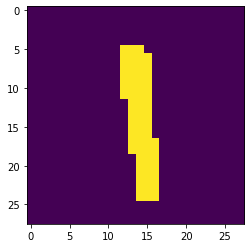

In [108]:
import matplotlib.pyplot as plt
training_data,test_data = load_data_wrapper(50000)
print(training_data[8])
lll8=np.reshape(training_data[8][0],(28,28))
plt.imshow(lll8)
plt.show()

Создайте нейронную сеть для распознавания рукописных цифр:


In [109]:
net = Network([784, 30, 10])
""" Вывод результата на экран: """ 
print('Сеть net:') 
print('Количетво слоев:', net.num_layers) 
for i in range(net.num_layers): 
    print('Количество нейронов в слое', i,':',net.sizes[i]) 
for i in range(net.num_layers-1): 
    print('W_',i+1,':') 
    print(np.round(net.weights[i],2)) 
    print('b_',i+1,':') 
    print(np.round(net.biases[i],2))
    

Сеть net:
Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 30
Количество нейронов в слое 2 : 10
W_ 1 :
[[-0.25  0.26  0.92 ... -0.18 -1.09 -0.52]
 [-1.8  -0.44  0.78 ...  0.23 -0.83 -0.5 ]
 [-0.66  0.08 -2.05 ...  1.72  0.38 -0.46]
 ...
 [ 0.1   0.01 -1.36 ... -0.46  1.27  2.5 ]
 [-1.46 -2.25  1.59 ... -1.33  0.96 -0.1 ]
 [-0.47  0.12 -0.4  ... -0.66 -0.01 -0.11]]
b_ 1 :
[[-0.43]
 [ 0.83]
 [ 0.32]
 [ 0.83]
 [ 1.2 ]
 [ 0.22]
 [-0.26]
 [ 0.32]
 [ 0.51]
 [ 1.05]
 [ 0.29]
 [-0.6 ]
 [ 0.08]
 [ 0.06]
 [ 2.29]
 [-0.44]
 [ 1.37]
 [ 0.37]
 [-0.89]
 [-0.1 ]
 [ 0.95]
 [-0.93]
 [-2.34]
 [-1.04]
 [-0.56]
 [-0.17]
 [ 1.2 ]
 [ 0.43]
 [-0.46]
 [-0.53]]
W_ 2 :
[[ 0.73  0.33  1.14 -1.44  0.04 -0.54 -0.34  0.63 -1.13  0.29  0.98  0.03
  -0.45 -1.65 -0.45 -0.47  1.11 -0.12 -0.32  0.28 -0.23 -1.08  0.6   0.98
   0.82  2.39  1.75 -1.17  1.27 -0.07]
 [-0.98 -1.7   0.85  0.4  -0.3   1.24  0.07  2.41 -1.83 -0.49 -0.52 -0.84
   0.1   0.58 -0.25 -0.76 -0.27  0.9  -0.38 -0.18  

Запустите процедуру обучения созданной нейронной сети, включающую 30 эпох:

In [110]:
net.SGD(training_data, 30, 10, 3.0, test_data=test_data)
#  , training_data # обучающая выборка
#         , epochs # количество эпох обучения
#         , mini_batch_size # размер подвыборки
#         , eta # скорость обучения
#         , test_data # тестирующая выборка

Epoch 0: 8838 / 10000
Epoch 1: 9069 / 10000
Epoch 2: 9132 / 10000
Epoch 3: 9187 / 10000
Epoch 4: 9304 / 10000
Epoch 5: 9301 / 10000
Epoch 6: 9354 / 10000
Epoch 7: 9354 / 10000
Epoch 8: 9363 / 10000
Epoch 9: 9351 / 10000
Epoch 10: 9336 / 10000
Epoch 11: 9363 / 10000
Epoch 12: 9394 / 10000
Epoch 13: 9354 / 10000
Epoch 14: 9393 / 10000
Epoch 15: 9401 / 10000
Epoch 16: 9389 / 10000
Epoch 17: 9403 / 10000
Epoch 18: 9396 / 10000
Epoch 19: 9382 / 10000
Epoch 20: 9378 / 10000
Epoch 21: 9386 / 10000
Epoch 22: 9407 / 10000
Epoch 23: 9402 / 10000
Epoch 24: 9424 / 10000
Epoch 25: 9409 / 10000
Epoch 26: 9414 / 10000
Epoch 27: 9334 / 10000
Epoch 28: 9434 / 10000
Epoch 29: 9418 / 10000


In [122]:
from sklearn.metrics import confusion_matrix

# Forward propagate input to a network output
def forward_propagate(net, row):
    inputs = row
    for i in range(net.num_layers-1):
        new_inputs = []
        for b, w in zip(net.biases[i], net.weights[i]):
            activation = np.dot(w,inputs)+b
            out = net.sigmoid(activation)
            new_inputs.append(out)
        inputs = new_inputs
    return new_inputs
		  


# Make a prediction with a network
def predict(net, row):
    outputs = forward_propagate(net, row)
    return outputs.index(max(outputs))

i=-1
X_train=[]
thresholdedData=[]

for i in range(len(x_train)):
    row=np.reshape(x_train[i], (1,784))
    thresholdedData = (row > 0) * 1.0
    X_train.extend(thresholdedData)


for i in range(len(X_train)):
    prediction = predict(net,X_train[i])
    if (i==0):
      predictTrain = np.array([[prediction]])
    else:
      predictTrain =np.append(predictTrain,[[prediction]],axis=0)

print(confusion_matrix(y_train, predictTrain))

60000
[[5799    2    8   12    8    9   26   11   42    6]
 [   1 6609   47   15    7    1    5   13   36    8]
 [  32   20 5718   27   21   14   26   46   49    5]
 [  17   15  109 5691    7   59   20   55  128   30]
 [   9   11   21    1 5552    2   21   26   35  164]
 [  33   11   27   84   11 5061   64   11   94   25]
 [  18   11   16    4   14   36 5795    0   23    1]
 [   7   19   30    9   27    1    6 6127   14   25]
 [  29   34   36   51    5   29   27   13 5591   36]
 [  22    7    6   48   60   33    4   57   49 5663]]
